In [5]:
# Adversarial regularization for image classification

#Train an image classifier using mnist

import keras
from keras.datasets import mnist
from keras.models import Model
from keras.layers import Dense, Dropout, Flatten ,Input
from keras.layers import Conv2D, MaxPooling2D, Reshape, Add
from keras.metrics import categorical_accuracy
from keras.regularizers import l1_l2, l2, l1
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.layers import Activation
from tensorflow.keras.utils import get_custom_objects
from tensorflow.python.keras import backend as K
from keras.preprocessing.image import array_to_img,img_to_array

import matplotlib.pyplot as plt
import numpy as np

#load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

#preprocess data
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255.
x_test /= 255.

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

#compile CNN network for MNIST classification 
inputs = Input(shape=(28,28,1))
net = Conv2D(32, kernel_size=(3, 3),
                 activation='relu')(inputs)
net = Conv2D(64, kernel_size=(3, 3),
                 activation='relu')(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Dropout(0.25)(net)
net = Flatten()(net)
net = Dense(128, activation='relu')(net)
net = Dropout(0.5)(net)
outputs = Dense(10, activation='softmax')(net)

mnist_model = Model(inputs=inputs, outputs=outputs, name='classification_model')
mnist_model.compile(optimizer='nadam', loss='categorical_crossentropy',metrics=["categorical_accuracy"])

#train MNIST classifer
earlyStop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

mnist_model.fit(x_train, y_train, batch_size=128, epochs=100, verbose=1, validation_data=(x_test, y_test),
               callbacks=[earlyStop])

print(mnist_model.evaluate(x_train, y_train))
print(mnist_model.evaluate(x_test, y_test))

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 87ms/step - categorical_accuracy: 0.9259 - loss: 0.2452 - val_categorical_accuracy: 0.9818 - val_loss: 0.0548
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - categorical_accuracy: 0.9746 - loss: 0.0857 - val_categorical_accuracy: 0.9872 - val_loss: 0.0375
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 50s 107ms/step - categorical_accuracy: 0.9816 - loss: 0.0626 - val_categorical_accuracy: 0.9879 - val_loss: 0.0353
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 77ms/step - categorical_accuracy: 0.9838 - loss: 0.0523 - val_categorical_accuracy: 0.9901 - val_loss: 0.0288
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 83ms/step - categorical_accuracy: 0.9860 - loss: 0.0442 - val_categorical_accuracy: 0.9885 - val_loss: 0.0365
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 83ms/step - categorical_accuracy: 0.9878 - loss: 0.0388 - val_categorical_accuracy: 0.9910 - val_loss: 0.0303
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - categorical_

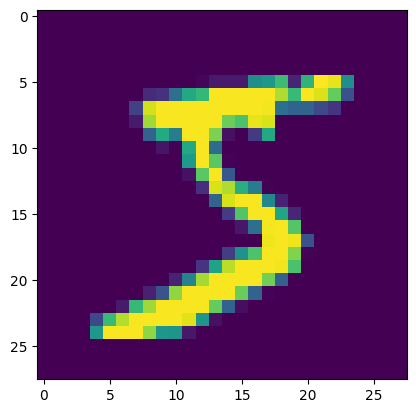

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
[3.8789079e-19 1.0900118e-15 6.3632050e-22 3.9032304e-05 9.8525454e-16
 9.9996102e-01 1.9762097e-14 1.4248446e-14 3.5409718e-12 1.0688757e-08]


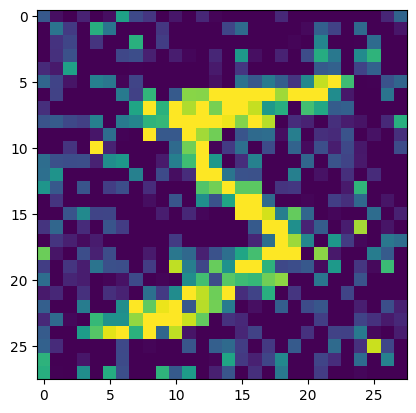

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
[5.2430497e-15 2.1567770e-11 7.6471515e-15 2.1911524e-02 2.0084474e-11
 9.7808504e-01 2.0690775e-12 1.6870056e-09 5.6531763e-10 3.3732522e-06]


In [6]:
#Select an image and apply some heavy random noise to the image and evaluate the noisy 
# image on the classification model as well.

img = x_train[0:1]
plt.imshow(img.reshape((28,28)),vmin=0., vmax=1.)
plt.show()
#varify accurate classificaiton
prediction = mnist_model.predict(img)[0]
print(prediction)

#applying random noise does not fool the classifier
quantized_noise = np.round(np.random.normal(loc=0.0, scale=0.3, size=img.shape) * 255.) / 255.
noisy_img = np.clip(img + quantized_noise, 0., 1.)
plt.imshow(noisy_img.reshape((28,28)),vmin=0., vmax=1.)
plt.show()
noisy_prediction = mnist_model.predict(noisy_img)[0]
print(noisy_prediction)

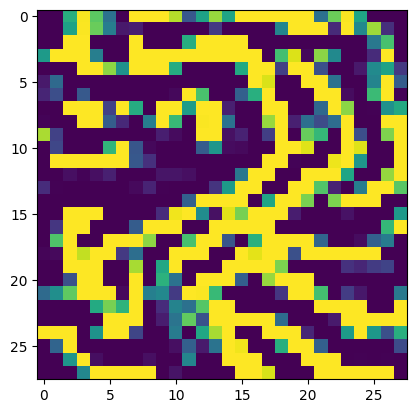

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
[[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]]


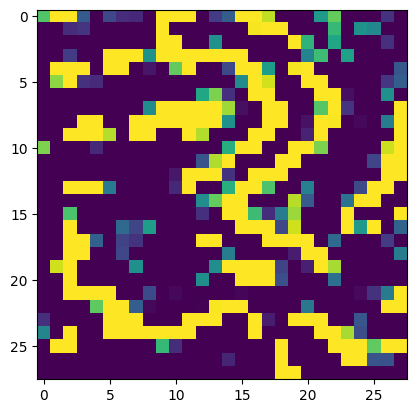

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[0.0000000e+00 0.0000000e+00 2.4868525e-16 1.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]]


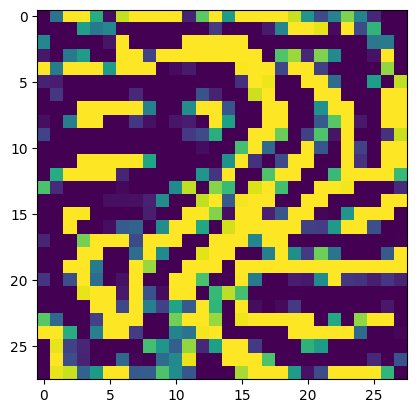

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
[[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]]


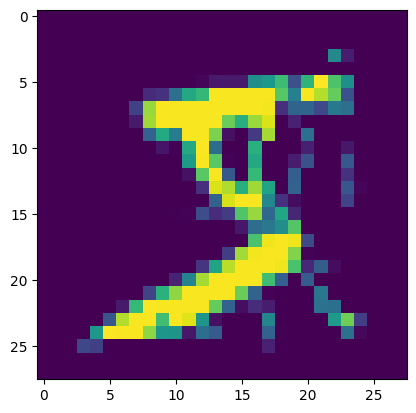

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
[[3.1579739e-11 2.3413523e-11 3.0500336e-10 5.5817811e-05 5.4965940e-06
  3.3817673e-04 1.4520723e-14 2.2372624e-05 1.3057439e-07 9.9957806e-01]]


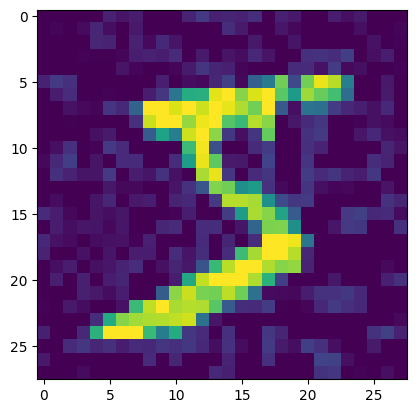

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
[[2.1164872e-09 9.5529789e-09 7.5767872e-09 9.7415216e-02 3.4567402e-05
  5.5073917e-01 8.0449486e-10 2.0768520e-04 4.5853603e-06 3.5159883e-01]]


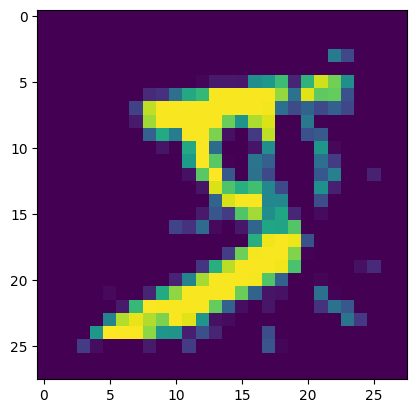

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
[[2.7119529e-10 2.1468289e-11 2.8327127e-10 1.2000858e-04 3.9272704e-06
  3.3852094e-04 3.5484257e-14 4.3318028e-05 3.2200441e-07 9.9949384e-01]]


array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [15]:
"""
create a new model, which is a copy of the trained classifier, but with additional preprocessing layers, 
as depicted in the network diagram. 
The adversarial_noise layer is a Dense layer that is fully connected to a placeholder input with 
a single constant value of 1. The bias for this layer is turned off, 
so each neuron in the adversarial_noise layer outputs the same value as the weight connecting it to the unity input.
"""

import os, datetime

#custom activation function for keeping adversarial pixel values between 0.0 and 1.0
def clip(x):
    return K.clip(x, 0.0, 1.0)

#custom loss funciton for non-targeted misclassification
def negative_categorical_crossentropy(yTrue,yPred):
    return 0.0 - K.categorical_crossentropy(yTrue,yPred)

#add custom objects to dictionary
get_custom_objects().update({'clip': Activation(clip)})
get_custom_objects().update({'negative_categorical_crossentropy': negative_categorical_crossentropy})


#function for generating an adversarial example given a base image, adversarial class target, classifier, and regularization type
def generate_adversary(img,target,model,regularization,loss_function):
    
    #input for base image
    image = Input(shape=(28,28,1),name='image')
    #unit input for adversarial noise
    one = Input(shape=(1,),name='unity')
    
    #layer for learning adversarial noise to apply to image
    noise = Dense(28*28,activation = None,use_bias=False,kernel_initializer='random_normal',
                  kernel_regularizer=regularization, name='adversarial_noise')(one)
    
    #reshape noise in shape of image
    noise = Reshape((28,28,1),name='reshape')(noise)
    
    #add noise to image
    net = Add(name='add')([noise,image])
    #clip values to be within 0.0 and 1.0
    net = Activation(clip, name='clip_values')(net)

    
    #feed adversarial image to trained MNIST classifier
    outputs = model(net)

    adversarial_model = Model(inputs=[image, one], outputs=outputs)
    #freeze trained MNIST classifier layers
    adversarial_model.layers[-1].trainable = False
    
    adversarial_model.compile(optimizer='nadam', loss=loss_function, metrics=[categorical_accuracy])
        
    #target adversarial classification
    target_vector = np.zeros(10)
    target_vector[target] = 1.
    
    #callback for saving weights with smallest loss
    save_dir = r"C:\Users\nisse\Skola\DIL700\Assignment4.5"
    os.makedirs(save_dir, exist_ok=True)

    weights_path = os.path.join(
        save_dir,
        f"adversarial_{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}.weights.h5"
    )


    checkpoint = ModelCheckpoint(weights_path, monitor='loss', verbose=0, save_best_only=True, save_weights_only=True,
                                 mode='auto')
    #train adversarial image
    adversarial_model.fit(x={'image':img,'unity':np.ones(shape=(1,1))},y=target_vector.reshape(1,-1),epochs=10000,verbose=0,
                         callbacks=[checkpoint])
    #restore best weights
    adversarial_model.load_weights(weights_path)
    
    #quantize adversarial noise
    quantized_weights = np.round(adversarial_model.get_weights()[0].reshape((28,28)) * 255.) / 255.
    
    #add trained weights to original image and clip values to produce adversarial image
    adversarial_img = np.clip(img.reshape((28,28)) + quantized_weights, 0., 1.)
    
    #display adversarial image
    plt.imshow(adversarial_img,vmin=0., vmax=1.)
    plt.show()
    #classify adversarial image
    adversarial_prediction = mnist_model.predict(adversarial_img.reshape((1,28,28,1)))
    print(adversarial_prediction)
    
    return adversarial_img

generate_adversary(img,5,mnist_model,l1(0.01),negative_categorical_crossentropy)
generate_adversary(img,5,mnist_model,l2(0.01),negative_categorical_crossentropy)
generate_adversary(img,5,mnist_model,l1_l2(l1=0.01,l2=0.01),negative_categorical_crossentropy)

generate_adversary(img,9,mnist_model,l1(0.01),'categorical_crossentropy')
generate_adversary(img,9,mnist_model,l2(0.01),'categorical_crossentropy')
generate_adversary(img,9,mnist_model,l1_l2(l1=0.01,l2=0.01),'categorical_crossentropy')